In [1]:
# Python Data preprocessing steps -  

# Understand the Business Problem
# Collect / Import the Raw Dataset
# Load Data into Python
# Explore the Dataset
# Check Data Quality
# Clean the Data in Python
# Handle Missing Values
# Remove Duplicates / Redundant Columns
# Standardize Column Names and Data Types
# Create New Features / Derived Columns

In [2]:
# ============================================================
# CUSTOMER SHOPPING BEHAVIOR
# DATA PREPROCESSING + EXPLORATORY DATA ANALYSIS
# ============================================================

In [3]:
# ------------------------------------------------------------
# 1. IMPORT LIBRARIES
# ------------------------------------------------------------
import pandas as pd
import numpy as np

In [4]:
# ------------------------------------------------------------
# 2. LOAD / IMPORT THE RAW DATASET
# ------------------------------------------------------------
df = pd.read_csv("E:/power bi/customer_shopping_behavior.csv")
print("Dataset loaded successfully!")

Dataset loaded successfully!


In [5]:
# ------------------------------------------------------------
# 3. UNDERSTAND THE BUSINESS PROBLEM
# ------------------------------------------------------------
"""
Business Problem:

The objective is to analyze customer shopping behavior and identify
patterns related to customer demographics, purchases, product
categories, payment methods, discounts, subscriptions, and
purchasing frequency.

Data preprocessing is performed to make the dataset suitable for
analysis, while EDA is used to identify important trends and
relationships in customer purchasing behavior.
"""

'\nBusiness Problem:\n\nThe objective is to analyze customer shopping behavior and identify\npatterns related to customer demographics, purchases, product\ncategories, payment methods, discounts, subscriptions, and\npurchasing frequency.\n\nData preprocessing is performed to make the dataset suitable for\nanalysis, while EDA is used to identify important trends and\nrelationships in customer purchasing behavior.\n'

In [6]:
# ------------------------------------------------------------
# 4. EXPLORE THE DATASET
# ------------------------------------------------------------

# Display first 5 rows
print("\nFirst 5 rows:")
print(df.head())


# Display last 5 rows
print("\nLast 5 rows:")
print(df.tail())


# Dataset dimensions
print("\nDataset shape:")
print(df.shape)


# Number of rows
print("\nNumber of rows:", df.shape[0])


# Number of columns
print("Number of columns:", df.shape[1])


# Display column names
print("\nColumn names:")
print(df.columns.tolist())


# Display data types
print("\nData types:")
print(df.dtypes)


# Dataset information
print("\nDataset information:")
df.info()


# Statistical summary
print("\nStatistical summary:")
print(df.describe(include="all"))


First 5 rows:
   Customer ID  Age Gender Item Purchased  Category  Purchase Amount (USD)  \
0            1   55   Male         Blouse  Clothing                     53   
1            2   19   Male        Sweater  Clothing                     64   
2            3   50   Male          Jeans  Clothing                     73   
3            4   21   Male        Sandals  Footwear                     90   
4            5   45   Male         Blouse  Clothing                     49   

        Location Size      Color  Season  Review Rating Subscription Status  \
0       Kentucky    L       Gray  Winter            3.1                 Yes   
1          Maine    L     Maroon  Winter            3.1                 Yes   
2  Massachusetts    S     Maroon  Spring            3.1                 Yes   
3   Rhode Island    M     Maroon  Spring            3.5                 Yes   
4         Oregon    M  Turquoise  Spring            2.7                 Yes   

   Shipping Type Discount Applied Promo C

In [7]:
# ------------------------------------------------------------
# 5. CHECK DATA QUALITY
# ------------------------------------------------------------

# Check missing values
print("\nMissing values:")
print(df.isnull().sum())


Missing values:
Customer ID                0
Age                        0
Gender                     0
Item Purchased             0
Category                   0
Purchase Amount (USD)      0
Location                   0
Size                       0
Color                      0
Season                     0
Review Rating             37
Subscription Status        0
Shipping Type              0
Discount Applied           0
Promo Code Used            0
Previous Purchases         0
Payment Method             0
Frequency of Purchases     0
dtype: int64


In [8]:
# Check percentage of missing values
print("\nMissing value percentage:")
print((df.isnull().sum() / len(df)) * 100)


Missing value percentage:
Customer ID               0.000000
Age                       0.000000
Gender                    0.000000
Item Purchased            0.000000
Category                  0.000000
Purchase Amount (USD)     0.000000
Location                  0.000000
Size                      0.000000
Color                     0.000000
Season                    0.000000
Review Rating             0.948718
Subscription Status       0.000000
Shipping Type             0.000000
Discount Applied          0.000000
Promo Code Used           0.000000
Previous Purchases        0.000000
Payment Method            0.000000
Frequency of Purchases    0.000000
dtype: float64


In [9]:
# Check duplicate rows
print("\nNumber of duplicate rows:")
print(df.duplicated().sum())


Number of duplicate rows:
0


In [10]:
# Check unique values in each column
print("\nNumber of unique values:")
print(df.nunique())


Number of unique values:
Customer ID               3900
Age                         53
Gender                       2
Item Purchased              25
Category                     4
Purchase Amount (USD)       81
Location                    50
Size                         4
Color                       25
Season                       4
Review Rating               26
Subscription Status          2
Shipping Type                6
Discount Applied             2
Promo Code Used              2
Previous Purchases          50
Payment Method               6
Frequency of Purchases       7
dtype: int64


In [11]:
# ------------------------------------------------------------
# 6. STANDARDIZE COLUMN NAMES
# ------------------------------------------------------------
df.columns = (
    df.columns
    .str.strip()
    .str.lower()
    .str.replace(r"[^a-z0-9]+", "_", regex=True)
    .str.strip("_")
)

print("\nStandardized column names:")
print(df.columns.tolist())


Standardized column names:
['customer_id', 'age', 'gender', 'item_purchased', 'category', 'purchase_amount_usd', 'location', 'size', 'color', 'season', 'review_rating', 'subscription_status', 'shipping_type', 'discount_applied', 'promo_code_used', 'previous_purchases', 'payment_method', 'frequency_of_purchases']


In [12]:
# create frequency puchase days columns
frequency_map = {
   "Every 3 Months" : 90,
"Annually" : 365 ,       
"Quarterly" :  90 ,      
"Monthly" :  30 ,        
"Bi-Weekly" :   14 ,    
"Fortnightly" :    14 ,  
"Weekly" : 7          
}

In [13]:
df["freq_purchase_days"] = df["frequency_of_purchases"].map(frequency_map)

# Remove discount_applied
df.drop(columns=["discount_applied"], inplace=True)

In [14]:
# ------------------------------------------------------------
# 7. CLEAN STRING COLUMNS
# ------------------------------------------------------------

# Find categorical/string columns
string_columns = df.select_dtypes(
    include=["object", "string"]
).columns

for column in string_columns:
    df[column] = df[column].astype("string").str.strip()

# Replace empty strings with NaN
df = df.replace("", np.nan)

In [15]:
# ------------------------------------------------------------
# 8. HANDLE MISSING VALUES
# ------------------------------------------------------------

print("\nMissing values before treatment:")
print(df.isnull().sum())

# Numeric columns
numeric_columns = df.select_dtypes(
    include=np.number
).columns

# Fill numerical missing values with median
for column in numeric_columns:
    if df[column].isnull().sum() > 0:
        df[column] = df[column].fillna(df[column].median())

# Categorical columns
categorical_columns = df.select_dtypes(
    include=["object", "string", "category"]
).columns

# Fill categorical missing values with mode
for column in categorical_columns:
    if df[column].isnull().sum() > 0:
        mode_value = df[column].mode()

        if len(mode_value) > 0:
            df[column] = df[column].fillna(mode_value[0])

print("\nMissing values after treatment:")
print(df.isnull().sum())


Missing values before treatment:
customer_id                0
age                        0
gender                     0
item_purchased             0
category                   0
purchase_amount_usd        0
location                   0
size                       0
color                      0
season                     0
review_rating             37
subscription_status        0
shipping_type              0
promo_code_used            0
previous_purchases         0
payment_method             0
frequency_of_purchases     0
freq_purchase_days         0
dtype: int64

Missing values after treatment:
customer_id               0
age                       0
gender                    0
item_purchased            0
category                  0
purchase_amount_usd       0
location                  0
size                      0
color                     0
season                    0
review_rating             0
subscription_status       0
shipping_type             0
promo_code_used           0
previo

In [16]:
# ------------------------------------------------------------
# 9. REMOVE DUPLICATES
# ------------------------------------------------------------

print("\nDuplicates before removal:", df.duplicated().sum())

df = df.drop_duplicates()

print("Duplicates after removal:", df.duplicated().sum())


Duplicates before removal: 0
Duplicates after removal: 0


In [17]:
# ------------------------------------------------------------
# 10. CHECK FOR REDUNDANT / CONSTANT COLUMNS
# ------------------------------------------------------------

constant_columns = []

for column in df.columns:
    if df[column].nunique() <= 1:
        constant_columns.append(column)

print("\nConstant columns:")
print(constant_columns)

# Remove constant columns
if len(constant_columns) > 0:
    df = df.drop(columns=constant_columns)


Constant columns:
[]


In [18]:
# ------------------------------------------------------------
# 11. CONVERT NUMERIC COLUMNS
# ------------------------------------------------------------
for column in df.columns:

    if df[column].dtype == "string":

        converted = pd.to_numeric(
            df[column],
            errors="coerce"
        )

        # Convert if almost all non-null values are numeric
        non_null = df[column].notnull().sum()

        if non_null > 0:
            numeric_ratio = converted.notnull().sum() / non_null

            if numeric_ratio >= 0.95:
                df[column] = converted

In [19]:
# ------------------------------------------------------------
# 12. CREATE NEW / DERIVED FEATURES
# ------------------------------------------------------------

# Age groups
if "age" in df.columns:

    df["age_group"] = pd.cut(
        df["age"],
        bins=[
            0,
            17,
            25,
            35,
            45,
            55,
            65,
            np.inf
        ],
        labels=[
            "<18",
            "18-25",
            "26-35",
            "36-45",
            "46-55",
            "56-65",
            "66+"
        ],
        include_lowest=True
    )


# Purchase amount bands
if "purchase_amount_usd" in df.columns:

    df["purchase_amount_band"] = pd.cut(
        df["purchase_amount_usd"],
        bins=[
            -np.inf,
            25,
            50,
            100,
            200,
            np.inf
        ],
        labels=[
            "<=25",
            "26-50",
            "51-100",
            "101-200",
            "200+"
        ]
    )

In [20]:
# ------------------------------------------------------------
# 13. VALIDATE CLEANED DATA
# ------------------------------------------------------------
print("\n==============================")
print("CLEANED DATASET VALIDATION")
print("==============================")

# Shape
print("\nFinal dataset shape:")
print(df.shape)

# Missing values
print("\nMissing values:")
print(df.isnull().sum())

# Duplicates
print("\nDuplicate rows:")
print(df.duplicated().sum())

# Data types
print("\nData types:")
print(df.dtypes)

# First rows
print("\nCleaned dataset:")
print(df.head())


CLEANED DATASET VALIDATION

Final dataset shape:
(3900, 20)

Missing values:
customer_id               0
age                       0
gender                    0
item_purchased            0
category                  0
purchase_amount_usd       0
location                  0
size                      0
color                     0
season                    0
review_rating             0
subscription_status       0
shipping_type             0
promo_code_used           0
previous_purchases        0
payment_method            0
frequency_of_purchases    0
freq_purchase_days        0
age_group                 0
purchase_amount_band      0
dtype: int64

Duplicate rows:
0

Data types:
customer_id                        int64
age                                int64
gender                    string[python]
item_purchased            string[python]
category                  string[python]
purchase_amount_usd                int64
location                  string[python]
size                      stri

In [21]:
# ------------------------------------------------------------
# 14. EXPLORATORY DATA ANALYSIS
# ------------------------------------------------------------
print("\n==============================")
print("EXPLORATORY DATA ANALYSIS")
print("==============================")

# ------------------------------------------------------------
# 14.1 Numerical Summary
# ------------------------------------------------------------
print("\nNumerical Summary:")
print(df.describe())


EXPLORATORY DATA ANALYSIS

Numerical Summary:
       customer_id          age  purchase_amount_usd  review_rating  \
count  3900.000000  3900.000000          3900.000000    3900.000000   
mean   1950.500000    44.068462            59.764359       3.750538   
std    1125.977353    15.207589            23.685392       0.713589   
min       1.000000    18.000000            20.000000       2.500000   
25%     975.750000    31.000000            39.000000       3.100000   
50%    1950.500000    44.000000            60.000000       3.800000   
75%    2925.250000    57.000000            81.000000       4.400000   
max    3900.000000    70.000000           100.000000       5.000000   

       previous_purchases  freq_purchase_days  
count         3900.000000         3900.000000  
mean            25.351538           89.133077  
std             14.447125          119.037566  
min              1.000000            7.000000  
25%             13.000000           14.000000  
50%             25.000000

In [22]:
# ------------------------------------------------------------
# 14.2 Categorical Variables
# ------------------------------------------------------------
for column in df.select_dtypes(
    include=["object", "string", "category"]
).columns:
    print("\n--------------------------------")
    print("Column:", column)
    print("--------------------------------")
    print(df[column].value_counts().head(10))


--------------------------------
Column: gender
--------------------------------
gender
Male      2652
Female    1248
Name: count, dtype: Int64

--------------------------------
Column: item_purchased
--------------------------------
item_purchased
Blouse        171
Pants         171
Jewelry       171
Shirt         169
Dress         166
Sweater       164
Jacket        163
Coat          161
Sunglasses    161
Belt          161
Name: count, dtype: Int64

--------------------------------
Column: category
--------------------------------
category
Clothing       1737
Accessories    1240
Footwear        599
Outerwear       324
Name: count, dtype: Int64

--------------------------------
Column: location
--------------------------------
location
Montana       96
California    95
Idaho         93
Illinois      92
Alabama       89
Minnesota     88
New York      87
Nevada        87
Nebraska      87
Delaware      86
Name: count, dtype: Int64

--------------------------------
Column: size
---------

In [23]:
# ------------------------------------------------------------
# 14.3 Gender Analysis
# ------------------------------------------------------------

if "gender" in df.columns:

    print("\nCustomer count by gender:")
    print(df["gender"].value_counts())


Customer count by gender:
gender
Male      2652
Female    1248
Name: count, dtype: Int64


In [24]:
# ------------------------------------------------------------
# 14.4 Age Group Analysis
# ------------------------------------------------------------

if "age_group" in df.columns:

    print("\nCustomer count by age group:")
    print(df["age_group"].value_counts().sort_index())


Customer count by age group:
age_group
<18        0
18-25    571
26-35    742
36-45    729
46-55    753
56-65    750
66+      355
Name: count, dtype: int64


In [25]:
# ------------------------------------------------------------
# 14.5 Product Category Analysis
# ------------------------------------------------------------

if "category" in df.columns:

    print("\nProduct category distribution:")
    print(df["category"].value_counts())


Product category distribution:
category
Clothing       1737
Accessories    1240
Footwear        599
Outerwear       324
Name: count, dtype: Int64


In [26]:
# ------------------------------------------------------------
# 14.6 Item Purchased Analysis
# ------------------------------------------------------------

if "item_purchased" in df.columns:

    print("\nTop 10 purchased items:")
    print(
        df["item_purchased"]
        .value_counts()
        .head(10)
    )


Top 10 purchased items:
item_purchased
Blouse        171
Pants         171
Jewelry       171
Shirt         169
Dress         166
Sweater       164
Jacket        163
Coat          161
Sunglasses    161
Belt          161
Name: count, dtype: Int64


In [27]:
# ------------------------------------------------------------
# 14.7 Purchase Amount Analysis
# ------------------------------------------------------------

if "purchase_amount_usd" in df.columns:

    print("\nPurchase amount statistics:")

    print(
        df["purchase_amount_usd"].describe()
    )


Purchase amount statistics:
count    3900.000000
mean       59.764359
std        23.685392
min        20.000000
25%        39.000000
50%        60.000000
75%        81.000000
max       100.000000
Name: purchase_amount_usd, dtype: float64


In [28]:
# ------------------------------------------------------------
# 14.8 Average Purchase by Gender
# ------------------------------------------------------------

if (
    "gender" in df.columns
    and "purchase_amount_usd" in df.columns
):

    print("\nAverage purchase amount by gender:")

    print(
        df.groupby("gender")["purchase_amount_usd"]
        .agg(["count", "mean", "median", "sum"])
        .sort_values("mean", ascending=False)
    )


Average purchase amount by gender:
        count       mean  median     sum
gender                                  
Female   1248  60.249199    60.0   75191
Male     2652  59.536199    60.0  157890


In [29]:
# ------------------------------------------------------------
# 14.9 Average Purchase by Category
# ------------------------------------------------------------
if (
    "category" in df.columns
    and "purchase_amount_usd" in df.columns
):

    print("\nPurchase amount by category:")

    print(
        df.groupby("category")["purchase_amount_usd"]
        .agg(["count", "mean", "median", "sum"])
        .sort_values("sum", ascending=False)
    )


Purchase amount by category:
             count       mean  median     sum
category                                     
Clothing      1737  60.025331    60.0  104264
Accessories   1240  59.838710    60.0   74200
Footwear       599  60.255426    60.0   36093
Outerwear      324  57.172840    54.5   18524


In [30]:
# ------------------------------------------------------------
# 14.10 Average Purchase by Age Group
# ------------------------------------------------------------
if (
    "age_group" in df.columns
    and "purchase_amount_usd" in df.columns
):
    print("\nPurchase amount by age group:")

    print(
        df.groupby(
            "age_group",
            observed=True
        )["purchase_amount_usd"]
        .agg(["count", "mean", "median", "sum"])
    )


Purchase amount by age group:
           count       mean  median    sum
age_group                                 
18-25        571  60.647986    62.0  34630
26-35        742  59.760108    60.0  44342
36-45        729  59.305898    59.0  43234
46-55        753  60.583001    62.0  45619
56-65        750  59.136000    58.5  44352
66+          355  58.884507    59.0  20904


In [31]:
# ------------------------------------------------------------
# 14.11 Payment Method Analysis
# ------------------------------------------------------------

if "payment_method" in df.columns:
    print("\nPayment method distribution:")
    print(df["payment_method"].value_counts())


Payment method distribution:
payment_method
PayPal           677
Credit Card      671
Cash             670
Debit Card       636
Venmo            634
Bank Transfer    612
Name: count, dtype: Int64


In [32]:
# ------------------------------------------------------------
# 14.12 Subscription Status Analysis
# ------------------------------------------------------------

if "subscription_status" in df.columns:
    print("\nSubscription status:")
    print(df["subscription_status"].value_counts())


Subscription status:
subscription_status
No     2847
Yes    1053
Name: count, dtype: Int64


In [33]:
# ------------------------------------------------------------
# 14.13 Discount Analysis
# ------------------------------------------------------------

if "discount_applied" in df.columns:

    print("\nDiscount applied:")
    print(df["discount_applied"].value_counts())

In [34]:
# ------------------------------------------------------------
# 14.14 Seasonal Analysis
# ------------------------------------------------------------

if (
    "season" in df.columns
    and "purchase_amount_usd" in df.columns
):

    print("\nSales by season:")

    print(
        df.groupby("season")["purchase_amount_usd"]
        .agg(["count", "mean", "sum"])
        .sort_values("sum", ascending=False)
    )    


Sales by season:
        count       mean    sum
season                         
Fall      975  61.556923  60018
Spring    999  58.737738  58679
Winter    971  60.357364  58607
Summer    955  58.405236  55777


In [35]:
# ------------------------------------------------------------
# 14.15 Correlation Analysis
# ------------------------------------------------------------

print("\nCorrelation Matrix:")

correlation_matrix = df.select_dtypes(
    include=np.number
).corr()

print(correlation_matrix)


Correlation Matrix:
                     customer_id       age  purchase_amount_usd  \
customer_id             1.000000 -0.004079             0.011048   
age                    -0.004079  1.000000            -0.010424   
purchase_amount_usd     0.011048 -0.010424             1.000000   
review_rating          -0.000430 -0.024263             0.029902   
previous_purchases     -0.039159  0.040445             0.008063   
freq_purchase_days      0.005380  0.016544             0.009526   

                     review_rating  previous_purchases  freq_purchase_days  
customer_id              -0.000430           -0.039159            0.005380  
age                      -0.024263            0.040445            0.016544  
purchase_amount_usd       0.029902            0.008063            0.009526  
review_rating             1.000000            0.003620            0.004341  
previous_purchases        0.003620            1.000000           -0.016996  
freq_purchase_days        0.004341           -0

In [36]:
# ------------------------------------------------------------
# 15. CHECK FOR NEGATIVE NUMERIC VALUES
# ------------------------------------------------------------

print("\nNegative values in numerical columns:")

for column in numeric_columns:

    if column in df.columns:

        negative_count = (df[column] < 0).sum()

        print(
            column,
            ":",
            negative_count
        )


Negative values in numerical columns:
customer_id : 0
age : 0
purchase_amount_usd : 0
review_rating : 0
previous_purchases : 0
freq_purchase_days : 0


In [37]:
# ------------------------------------------------------------
# 16. FINAL DATASET INFORMATION
# ------------------------------------------------------------

print("\n==============================")
print("FINAL DATASET")
print("==============================")

print(df.info())

print("\nFinal shape:", df.shape)


FINAL DATASET
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3900 entries, 0 to 3899
Data columns (total 20 columns):
 #   Column                  Non-Null Count  Dtype   
---  ------                  --------------  -----   
 0   customer_id             3900 non-null   int64   
 1   age                     3900 non-null   int64   
 2   gender                  3900 non-null   string  
 3   item_purchased          3900 non-null   string  
 4   category                3900 non-null   string  
 5   purchase_amount_usd     3900 non-null   int64   
 6   location                3900 non-null   string  
 7   size                    3900 non-null   string  
 8   color                   3900 non-null   string  
 9   season                  3900 non-null   string  
 10  review_rating           3900 non-null   float64 
 11  subscription_status     3900 non-null   string  
 12  shipping_type           3900 non-null   string  
 13  promo_code_used         3900 non-null   string  
 14  previous_

In [38]:
# ------------------------------------------------------------
# 17. SAVE CLEANED DATASET
# ------------------------------------------------------------

df.to_csv(
    "customer_shopping_behavior_cleaned.csv",
    index=False
)

print("\nCleaned dataset saved successfully!")


Cleaned dataset saved successfully!


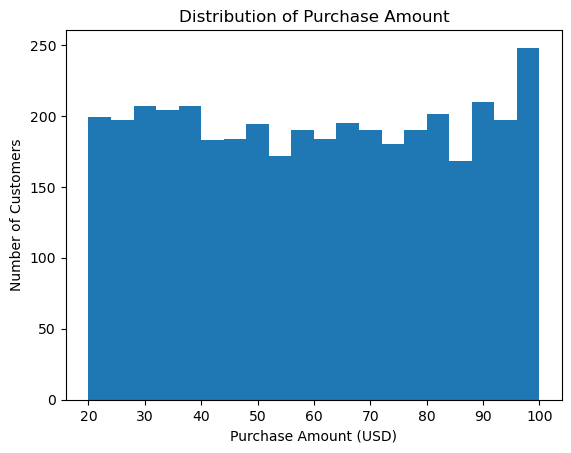

In [39]:
# ============================================================
# END OF DATA PREPROCESSING + EDA
# ============================================================
import matplotlib.pyplot as plt

# Purchase amount distribution
if "purchase_amount_usd" in df.columns:

    df["purchase_amount_usd"].plot(
        kind="hist",
        bins=20
    )

    plt.title("Distribution of Purchase Amount")
    plt.xlabel("Purchase Amount (USD)")
    plt.ylabel("Number of Customers")
    plt.show()

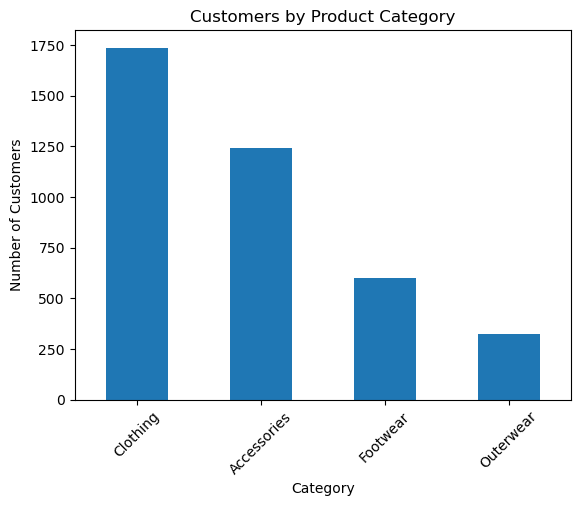

In [40]:
# Customer count by category
if "category" in df.columns:

    df["category"].value_counts().plot(
        kind="bar"
    )

    plt.title("Customers by Product Category")
    plt.xlabel("Category")
    plt.ylabel("Number of Customers")
    plt.xticks(rotation=45)
    plt.show()

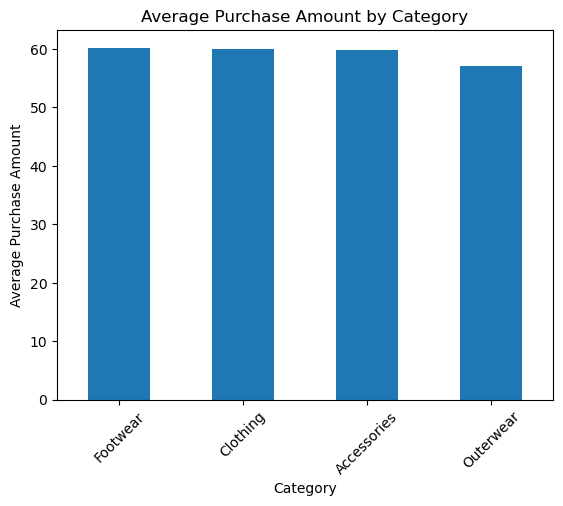

In [41]:
# Average purchase by category
if (
    "category" in df.columns
    and "purchase_amount_usd" in df.columns
):

    (
        df.groupby("category")["purchase_amount_usd"]
        .mean()
        .sort_values(ascending=False)
        .plot(kind="bar")
    )

    plt.title("Average Purchase Amount by Category")
    plt.xlabel("Category")
    plt.ylabel("Average Purchase Amount")
    plt.xticks(rotation=45)
    plt.show()

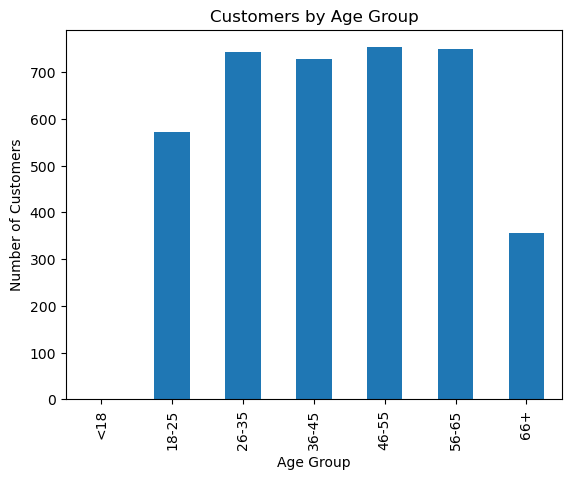

In [42]:
# Customer count by age group
if "age_group" in df.columns:

    df["age_group"].value_counts().sort_index().plot(
        kind="bar"
    )

    plt.title("Customers by Age Group")
    plt.xlabel("Age Group")
    plt.ylabel("Number of Customers")
    plt.show()


Sales by season:
        count       mean    sum
season                         
Fall      975  61.556923  60018
Spring    999  58.737738  58679
Winter    971  60.357364  58607
Summer    955  58.405236  55777


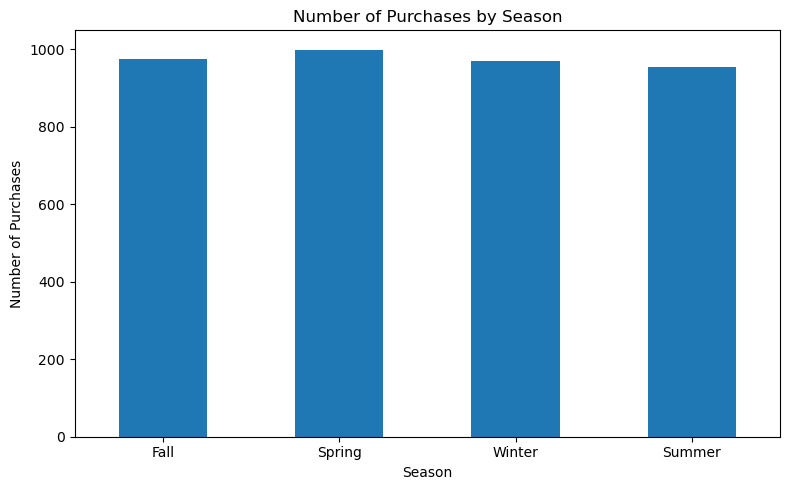

In [43]:
# Seasonal Analysis

if (
    "season" in df.columns
    and "purchase_amount_usd" in df.columns
):

    print("\nSales by season:")

    seasonal_sales = (
        df.groupby("season")["purchase_amount_usd"]
        .agg(["count", "mean", "sum"])
        .sort_values("sum", ascending=False)
    )

    print(seasonal_sales)

    # Graph: Number of purchases by season
    plt.figure(figsize=(8, 5))

    seasonal_sales["count"].plot(kind="bar")

    plt.title("Number of Purchases by Season")
    plt.xlabel("Season")
    plt.ylabel("Number of Purchases")
    plt.xticks(rotation=0)
    plt.tight_layout()
    plt.show()

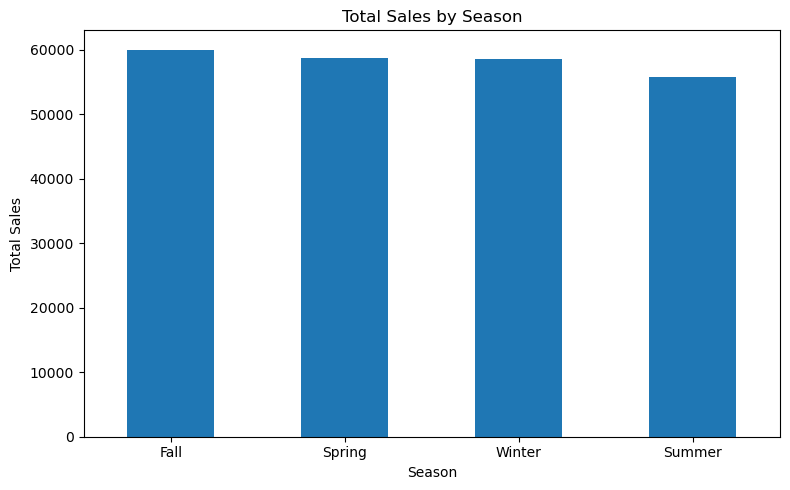

In [44]:
plt.figure(figsize=(8, 5))

seasonal_sales["sum"].plot(kind="bar")
# seasonal_sales["mean"].plot(kind="bar")  ---> average sales by season

plt.title("Total Sales by Season")
plt.xlabel("Season")
plt.ylabel("Total Sales")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

<h5>Importing the preprocessed cleaned dataset into mysql using python</h5>
<p>Further, after data cleaning in python, install the sqlalchemy library and importing the dataset in mysql.</p>

In [45]:
%pip install pymysql sqlalchemy

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [46]:
from sqlalchemy import create_engine
from urllib.parse import quote_plus

In [50]:
# the workflow -->
# python dataframe
# sqlalchemy
# pymysql - allows python to communicate with mysql
# mysql
# database
# table

# my sql connection
username="root"
password=quote_plus("root") 
host="localhost"
port="3306"
database="customer_shopping_behavior"

engine=create_engine(f"mysql+pymysql://{username}:{password}@{host}:{port}/{database}")

In [51]:
# write dataframe to  MYSQL

table_name="customer"  # choose any table name
df.to_sql(table_name, engine, if_exists="replace", index=False)

# read batch sample
pd.read_sql("SELECT * FROM customer LIMIT 5 ;",engine)

,customer_id,age,gender,item_purchased,category,purchase_amount_usd,location,size,color,season,review_rating,subscription_status,shipping_type,promo_code_used,previous_purchases,payment_method,frequency_of_purchases,freq_purchase_days,age_group,purchase_amount_band
0,1,55,Male,Blouse,Clothing,53,Kentucky,L,Gray,Winter,3.1,Yes,Express,Yes,14,Venmo,Fortnightly,14,46-55,51-100
1,2,19,Male,Sweater,Clothing,64,Maine,L,Maroon,Winter,3.1,Yes,Express,Yes,2,Cash,Fortnightly,14,18-25,51-100
2,3,50,Male,Jeans,Clothing,73,Massachusetts,S,Maroon,Spring,3.1,Yes,Free Shipping,Yes,23,Credit Card,Weekly,7,46-55,51-100
3,4,21,Male,Sandals,Footwear,90,Rhode Island,M,Maroon,Spring,3.5,Yes,Next Day Air,Yes,49,PayPal,Weekly,7,18-25,51-100
4,5,45,Male,Blouse,Clothing,49,Oregon,M,Turquoise,Spring,2.7,Yes,Free Shipping,Yes,31,PayPal,Annually,365,36-45,26-50


In [ ]:
# from sqlalchemy import create_engine

# username = "root"
# password = ""
# host = "localhost"
# port = "3306"
# database = "customer_behavior"

# engine = create_engine(
#     f"mysql+pymysql://{username}:{password}@{host}:{port}/{database}"
# )

# with engine.connect() as connection:
#     print("MySQL connected successfully!")